In this notebook, we will make some plots trying to show the different physical nature of ELG galaxies relative to BGS-B etc.


Notes: 
[OII] is typically strong in ELG
Ting-Wen Lan (10 mins) - The Diversity of ELG [OII] Line Profiles and its links to Star-formation and Morphology

In [20]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


import numpy as np
import h5py
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Key emission lines for reference (rest-frame wavelengths in Angstroms)
emission_lines = {
    r"[OII] $\lambda$3727": 3727.0,
    r"H$\beta$": 4861.0,
    r"[OIII] $\lambda$4959": 4959.0,
    r"[OIII] $\lambda$5007": 5007.0,
    r"H$\alpha$": 6563.0,
    r"[NII] $\lambda$6584": 6584.0,
    r"[SII] $\lambda$6717": 6717.0,
    r"[SII] $\lambda$6731": 6731.0,
}

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


In [18]:
# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
tot_cat = Table.read(filename, hdu="MAIN")

tot_cat =  tot_cat[(tot_cat["DWARF_MASKBIT"] == 0)]


In [21]:
# ============================================================================
# Data Loading Functions
# ============================================================================

def load_catalog(filename):
    """Load and filter the dwarf galaxy catalog."""
    tot_cat = Table.read(filename, hdu="MAIN")
    tot_cat = tot_cat[(tot_cat["DWARF_MASKBIT"] == 0)]
    return tot_cat


def load_spectra(h5_file):
    """Load de-redshifted spectra from HDF5 file."""
    with h5py.File(h5_file, "r") as f:
        data = {
            "targetid": f["TARGETID"][:],
            "z": f["Z"][:],
            "wave_rest": f["WAVE_REST"][:],
            "flux": f["FLUX"][:],
            "flux_ivar": f["FLUX_IVAR"][:]
        }
    return data


def select_sample(catalog, sample_name, z_min=0.05, z_max=0.1, 
                  logmstar_min=8.0, logmstar_max=8.5):
    """Select galaxies matching sample criteria."""
    mask = (
        (catalog["SAMPLE"] == sample_name) &
        (catalog["Z"] > z_min) &
        (catalog["Z"] < z_max) &
        (catalog["LOG_MSTAR_M24"] > logmstar_min) &
        (catalog["LOG_MSTAR_M24"] < logmstar_max)
    )
    return catalog[mask]



In [95]:
def get_sample_spectra_with_halpha(catalog_subset, spectra_data, halpha_col=HALPHA_FLUX_COLUMN):
    """
    Extract spectra for galaxies in the catalog subset, along with their Halpha fluxes.
    
    Returns
    -------
    fluxes : 2D array (n_spectra, n_wavelengths)
    ivars : 2D array (n_spectra, n_wavelengths)
    halpha_fluxes : 1D array (n_spectra,) - Halpha flux from catalog
    n_matched : int
    """
    cat_targetids = catalog_subset["TARGETID"]
    cat_halpha = catalog_subset[halpha_col]
    spec_targetids = spectra_data["targetid"]
    
    # Fast lookup
    spec_id_to_idx = {tid: idx for idx, tid in enumerate(spec_targetids)}
    
    matched_spec_indices = []
    matched_cat_indices = []
    
    for i, tid in enumerate(cat_targetids):
        if tid in spec_id_to_idx:
            matched_spec_indices.append(spec_id_to_idx[tid])
            matched_cat_indices.append(i)
    
    matched_spec_indices = np.array(matched_spec_indices)
    matched_cat_indices = np.array(matched_cat_indices)
    
    if len(matched_spec_indices) == 0:
        return None, None, None, 0
    
    fluxes = spectra_data["flux"][matched_spec_indices]
    ivars = spectra_data["flux_ivar"][matched_spec_indices]
    halpha_fluxes = np.array(cat_halpha[matched_cat_indices])
    
    return fluxes, ivars, halpha_fluxes, len(matched_spec_indices)


# ============================================================================
# Normalization Functions
# ============================================================================

def normalize_by_continuum(fluxes, ivars, wave, window=CONTINUUM_WINDOW):
    """
    Normalize each spectrum by median flux in continuum window.
    
    Returns
    -------
    norm_fluxes : 2D array - normalized fluxes
    norm_ivars : 2D array - scaled inverse variances
    norm_factors : 1D array - normalization factors used
    valid_mask : 1D boolean array - which spectra had valid normalization
    """
    wmin, wmax = window
    wave_mask = (wave >= wmin) & (wave <= wmax)
    
    n_spec = fluxes.shape[0]
    norm_factors = np.zeros(n_spec)
    valid_mask = np.zeros(n_spec, dtype=bool)
    
    for i in range(n_spec):
        flux_window = fluxes[i, wave_mask]
        good = np.isfinite(flux_window) & (flux_window > 0)
        if np.sum(good) > 10:
            norm_factors[i] = np.nanmedian(flux_window[good])
            valid_mask[i] = True
    
    # Normalize
    norm_fluxes = np.zeros_like(fluxes)
    norm_ivars = np.zeros_like(ivars)
    
    for i in range(n_spec):
        if valid_mask[i] and norm_factors[i] > 0:
            norm_fluxes[i] = fluxes[i] / norm_factors[i]
            norm_ivars[i] = ivars[i] * norm_factors[i]**2
    
    return norm_fluxes, norm_ivars, norm_factors, valid_mask


def normalize_by_halpha_catalog(fluxes, ivars, halpha_fluxes):
    """
    Normalize each spectrum by its Halpha flux from the catalog.
    
    Parameters
    ----------
    fluxes : 2D array (n_spectra, n_wavelengths)
    ivars : 2D array (n_spectra, n_wavelengths)
    halpha_fluxes : 1D array (n_spectra,) - Halpha fluxes from catalog
    
    Returns
    -------
    norm_fluxes : 2D array - normalized fluxes
    norm_ivars : 2D array - scaled inverse variances  
    valid_mask : 1D boolean array - which spectra had valid Halpha
    """
    n_spec = fluxes.shape[0]
    valid_mask = np.isfinite(halpha_fluxes) & (halpha_fluxes > 0)
    
    norm_fluxes = np.zeros_like(fluxes)
    norm_ivars = np.zeros_like(ivars)
    
    for i in range(n_spec):
        if valid_mask[i]:
            norm_fluxes[i] = fluxes[i] / halpha_fluxes[i]
            norm_ivars[i] = ivars[i] * halpha_fluxes[i]**2
    
    n_valid = np.sum(valid_mask)
    print(f"    Halpha normalization: {n_valid}/{n_spec} spectra with valid Halpha flux")
    
    return norm_fluxes, norm_ivars, valid_mask


# ============================================================================
# Stacking Functions
# ============================================================================

def simple_mean_stack(fluxes, ivars=None):
    """
    Simple mean stack (equal weight per spectrum).
    """
    valid = np.isfinite(fluxes)
    fluxes_masked = np.where(valid, fluxes, np.nan)
    
    stacked_flux = np.nanmean(fluxes_masked, axis=0)
    
    n_good = np.sum(valid, axis=0)
    stacked_std = np.nanstd(fluxes_masked, axis=0)
    stacked_error = stacked_std / np.sqrt(np.maximum(n_good, 1))
    
    return stacked_flux, stacked_error


def inverse_variance_stack(fluxes, ivars):
    """
    Inverse variance weighted stack.
    """
    valid_mask = np.isfinite(fluxes) & np.isfinite(ivars) & (ivars > 0)
    fluxes_clean = np.where(valid_mask, fluxes, 0)
    ivars_clean = np.where(valid_mask, ivars, 0)
    
    sum_weights = np.sum(ivars_clean, axis=0)
    weighted_flux_sum = np.sum(fluxes_clean * ivars_clean, axis=0)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        stacked_flux = np.where(sum_weights > 0, weighted_flux_sum / sum_weights, np.nan)
        stacked_error = np.where(sum_weights > 0, 1.0 / np.sqrt(sum_weights), np.nan)
    
    return stacked_flux, stacked_error


def bootstrap_stack(fluxes, ivars, halpha_fluxes, wave, n_bootstrap=200,
                    method='continuum_mean', random_seed=42):
    """
    Bootstrap resampled stacking.
    
    Parameters
    ----------
    fluxes : 2D array (n_spectra, n_wavelengths)
    ivars : 2D array
    halpha_fluxes : 1D array - Halpha fluxes from catalog
    wave : 1D array
    n_bootstrap : int
    method : str - 'ivar', 'continuum_mean', or 'halpha_mean'
    random_seed : int
    
    Returns
    -------
    stacked_flux : 1D array - mean over bootstrap samples
    stacked_error : 1D array - std over bootstrap samples
    all_stacks : 2D array (n_bootstrap, n_wavelengths)
    """
    np.random.seed(random_seed)
    n_spec, n_wave = fluxes.shape
    
    all_stacks = np.zeros((n_bootstrap, n_wave))
    
    # Pre-normalize based on method
    if method == 'continuum_mean':
        norm_fluxes, norm_ivars, _, valid = normalize_by_continuum(fluxes, ivars, wave)
        use_fluxes = norm_fluxes[valid]
        use_ivars = norm_ivars[valid]
    elif method == 'halpha_mean':
        norm_fluxes, norm_ivars, valid = normalize_by_halpha_catalog(fluxes, ivars, halpha_fluxes)
        use_fluxes = norm_fluxes[valid]
        use_ivars = norm_ivars[valid]
    else:  # ivar method
        valid = np.any(np.isfinite(fluxes) & (ivars > 0), axis=1)
        use_fluxes = fluxes[valid]
        use_ivars = ivars[valid]
    
    n_valid = use_fluxes.shape[0]
    
    if n_valid < 3:
        print(f"    Warning: Only {n_valid} valid spectra for bootstrap")
        return np.full(n_wave, np.nan), np.full(n_wave, np.nan), all_stacks
    
    for i in tqdm(range(n_bootstrap), desc="    Bootstrap", leave=False):
        indices = np.random.choice(n_valid, size=n_valid, replace=True)
        boot_fluxes = use_fluxes[indices]
        boot_ivars = use_ivars[indices]
        
        if method == 'ivar':
            stack, _ = inverse_variance_stack(boot_fluxes, boot_ivars)
        else:
            stack, _ = simple_mean_stack(boot_fluxes, boot_ivars)
        
        all_stacks[i] = stack
    
    stacked_flux = np.nanmean(all_stacks, axis=0)
    stacked_error = np.nanstd(all_stacks, axis=0)
    
    return stacked_flux, stacked_error, all_stacks


NameError: name 'HALPHA_FLUX_COLUMN' is not defined

In [15]:
print(len(tot_cat_elg))
print(len(tot_cat_bgsf))
print(len(tot_cat_bgsb))

7053
874
115


In [24]:
# File paths
catalog_file = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"
spectra_file = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/desi_y1_dwarf_combine_deredshift.h5"


# Load data
print("\n[1] Loading catalog...")
tot_cat = load_catalog(catalog_file)
print(f"    Total galaxies after masking: {len(tot_cat)}")

print("\n[2] Loading spectra...")
spectra_data = load_spectra(spectra_file)
print(f"    Total spectra loaded: {len(spectra_data['targetid'])}")

wave = spectra_data["wave_rest"]
print(f"    Wavelength range: {wave.min():.1f} - {wave.max():.1f} Angstroms")




[1] Loading catalog...
    Total galaxies after masking: 350118

[2] Loading spectra...
    Total spectra loaded: 368807
    Wavelength range: 3600.0 - 8999.2 Angstroms


In [96]:

# Selection parameters
z_min, z_max = 0.0, 0.05
logmstar_min, logmstar_max = 6, 9.25

In [97]:
# Select samples
print("\n[3] Selecting samples...")
samples = {
    "ELG": select_sample(tot_cat, "ELG", z_min, z_max, logmstar_min, logmstar_max),
    "BGS_BRIGHT": select_sample(tot_cat, "BGS_BRIGHT", z_min, z_max, logmstar_min, logmstar_max),
    "BGS_FAINT": select_sample(tot_cat, "BGS_FAINT", z_min, z_max, logmstar_min, logmstar_max),
}


[3] Selecting samples...


In [98]:
for name, cat in samples.items():
    print(f"    {name}: {len(cat)} galaxies in catalog")

    ELG: 3515 galaxies in catalog
    BGS_BRIGHT: 78201 galaxies in catalog
    BGS_FAINT: 6930 galaxies in catalog


In [99]:
print("\n[4] Stacking spectra...")
stacked_results = {}
for sample_name, catalog_subset in samples.items():
    flux, error, n_spec = stack_sample(catalog_subset, spectra_data, sample_name)
    stacked_results[sample_name] = (flux, error, n_spec)


[4] Stacking spectra...
  ELG: Found 3515 matching spectra
  BGS_BRIGHT: Found 78201 matching spectra
  BGS_FAINT: Found 6930 matching spectra


In [100]:
wave[1900]

5575.7397

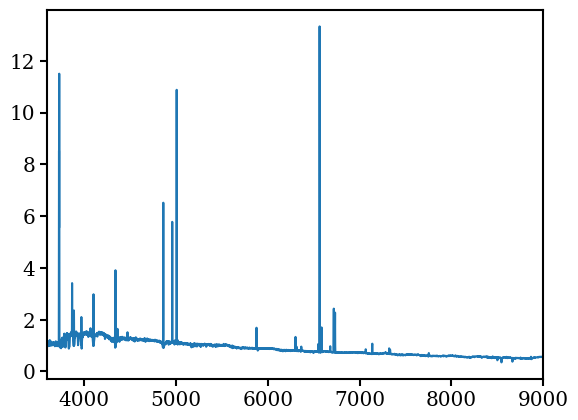

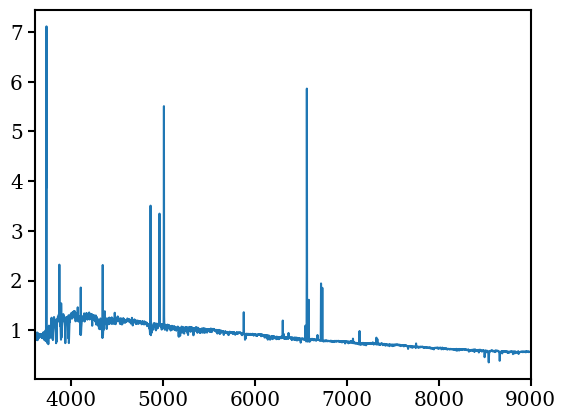

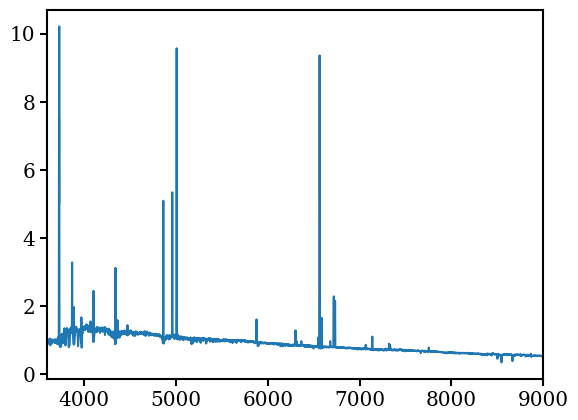

In [101]:
plt.plot(wave, stacked_results["ELG"][0] / stacked_results["ELG"][0][1900] )
plt.xlim([3600,9000])
plt.show()

plt.plot(wave, stacked_results["BGS_BRIGHT"][0] / stacked_results["BGS_BRIGHT"][0][1900])
plt.xlim([3600,9000])
plt.show()

plt.plot(wave, stacked_results["BGS_FAINT"][0] / stacked_results["BGS_FAINT"][0][1900])
plt.xlim([3600,9000])
plt.show()